# SentinelMail — Bi-LSTM + char-CNN: Training & Evaluation

Trains `models/bilstm/BiLSTMCharCNN` on the ai4privacy training split and evaluates
it on the validation split. Saves metrics to `evaluation/results/bilstm_metrics.json`
for ensemble comparison.

**Prerequisites**
- GloVe 6B 100d at `data/embeddings/glove.6B.100d.txt` (word channel is FROZEN, ADR-002).
  Download and extract just the 100d file:
  ```
  mkdir -p data/embeddings
  wget https://nlp.stanford.edu/data/glove.6B.zip
  unzip -j glove.6B.zip glove.6B.100d.txt -d data/embeddings/
  ```
  The loader HARD-FAILS if this file is absent (comment 012) so a random-init run
  can't be silently reported as the specified GloVe design.
- PyTorch installed (`pip install torch`)

## 0. Setup

In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

CHECKPOINT_DIR = REPO_ROOT / "models" / "bilstm" / "checkpoint"
GLOVE_PATH     = REPO_ROOT / "data" / "embeddings" / "glove.6B.100d.txt"
RESULTS_DIR    = REPO_ROOT / "evaluation" / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")
print(f"GloVe available: {GLOVE_PATH.exists()}")

Device: mps
GloVe available: True


In [14]:
from data.preprocessing import load_split, LABEL_COLS
from models.bilstm.vocab   import Vocabulary
from models.bilstm.dataset import DLPTextDataset, collate_fn
from models.bilstm.model   import BiLSTMCharCNN
from models.bilstm.predict import BiLSTMDLPDetector
from evaluation import (
    compute_all_metrics,
    classify_errors,
    error_summary,
    plot_confusion_matrices,
    plot_per_label_bars,
    plot_roc_curves,
    plot_pr_curves,
    save_results,
    from_dataframe,
    LABEL_COLS,
)

## 1. Load Data

In [3]:
print("Loading splits...")
train_df = load_split("train")
val_df   = load_split("validation")

train_texts  = train_df["source_text"].tolist()
val_texts    = val_df["source_text"].tolist()
train_labels = train_df[LABEL_COLS].values.astype(np.float32)
val_labels   = val_df[LABEL_COLS].values.astype(np.float32)

print(f"Train: {len(train_texts):,} samples")
print(f"Val:   {len(val_texts):,} samples")
print()
print("Label distribution (train):")
print(train_df[LABEL_COLS].sum().to_string())

Loading splits...


Train: 29,908 samples
Val:   7,946 samples

Label distribution (train):
benign           3482
PII             26426
financial        5688
confidential    13252


## 2. Build Vocabulary

In [6]:
VOCAB_PATH = CHECKPOINT_DIR / "vocab.json"

if VOCAB_PATH.exists():
    vocab = Vocabulary.load(VOCAB_PATH)
    print(f"Loaded existing vocabulary from {VOCAB_PATH}")
else:
    vocab = Vocabulary()
    vocab.build_from_texts(train_texts, min_freq=2)
    print("Built vocabulary from training data")

print(f"Words: {vocab.n_words:,}  |  Chars: {vocab.n_chars}")

Loaded existing vocabulary from /Users/erelv/projects-chkp/final-project/models/bilstm/checkpoint/vocab.json
Words: 43,447  |  Chars: 290


## 3. Load GloVe Embeddings

In [7]:
# Reuse the canonical loader from models.bilstm.train so the notebook and CLI can
# never diverge. It HARD-FAILS if GloVe is missing (comment 012); set
# ALLOW_RANDOM_INIT=True only to run an explicit random-init variant, which is then
# recorded as glove_loaded=false. The real loaded status (GLOVE_LOADED) is threaded
# into the model freeze decision and the saved metadata below.
from models.bilstm.train import _load_glove

ALLOW_RANDOM_INIT = False  # keep False for the specified GloVe design

pretrained_emb, GLOVE_LOADED = _load_glove(
    GLOVE_PATH, vocab, allow_random_init=ALLOW_RANDOM_INIT
)
print(f"GLOVE_LOADED = {GLOVE_LOADED}")

GloVe: 12501/43445 vocab words initialised from GloVe vectors.
GLOVE_LOADED = True


## 4. Datasets & DataLoaders

In [8]:
BATCH_SIZE = 64

train_ds = DLPTextDataset(train_texts, train_labels, vocab)
val_ds   = DLPTextDataset(val_texts,   val_labels,   vocab)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, num_workers=2, pin_memory=(DEVICE.type == "cuda"),
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_fn, num_workers=2,
)

print(f"Train batches: {len(train_loader):,}  |  Val batches: {len(val_loader):,}")

Train batches: 468  |  Val batches: 125


## 5. Initialise Model

In [9]:
# Freeze the word channel only when real GloVe was loaded; freezing a random matrix
# would train on frozen noise (comment 012). USE_CHAR_CNN toggles the ablation.
USE_CHAR_CNN = True
model = BiLSTMCharCNN(
    vocab.n_words, vocab.n_chars, pretrained_emb=pretrained_emb,
    freeze_word_emb=GLOVE_LOADED, use_char_cnn=USE_CHAR_CNN,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
_froze = "frozen" if GLOVE_LOADED else "trainable (random init)"
print(f"Trainable params: {trainable_params:,}  (word embedding {_froze})")

Total params:     7,076,284
Trainable params: 2,731,584  (word embedding frozen)


## 6. Train

Skip this cell if `checkpoint/best_model.pt` already exists — the next section loads it.

In [8]:
EPOCHS = 20
LR     = 1e-3
CKPT   = CHECKPOINT_DIR / "best_model.pt"

def _pos_weights(labels: np.ndarray, device: torch.device) -> torch.Tensor:
    pos = labels.sum(axis=0).clip(1)
    neg = len(labels) - pos
    return torch.tensor(neg / pos, dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=_pos_weights(train_labels, DEVICE))
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=LR
)

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for word_ids, char_ids, mask, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d} train", leave=False):
        word_ids, char_ids, mask, labels = (
            word_ids.to(DEVICE), char_ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        )
        optimizer.zero_grad()
        loss = criterion(model(word_ids, char_ids, mask), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for word_ids, char_ids, mask, labels in val_loader:
            word_ids, char_ids, mask, labels = (
                word_ids.to(DEVICE), char_ids.to(DEVICE), mask.to(DEVICE), labels.to(DEVICE)
            )
            val_loss += criterion(model(word_ids, char_ids, mask), labels).item()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    marker = "  ✓ saved" if avg_val < best_val_loss else ""
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), CKPT)
        vocab.save(CHECKPOINT_DIR / "vocab.json")
    print(f"Epoch {epoch:02d}/{EPOCHS}  train={avg_train:.4f}  val={avg_val:.4f}{marker}")

print(f"\nBest val loss: {best_val_loss:.4f}  →  {CKPT}")

Epoch 01/20  train=0.4822  val=0.3473  ✓ saved


Epoch 02/20  train=0.2667  val=0.2406  ✓ saved


Epoch 03/20  train=0.1843  val=0.1977  ✓ saved


Epoch 04/20  train=0.1458  val=0.1813  ✓ saved


Epoch 05/20  train=0.1186  val=0.1889


...

Epoch 16/20  train=0.0254  val=0.3259


Epoch 17/20  train=0.0277  val=0.2892


Epoch 18/20  train=0.0245  val=0.2709


Epoch 19/20  train=0.0233  val=0.3181


Epoch 20/20  train=0.0189  val=0.2931

Best val loss: 0.1761  →  /Users/erelv/projects-chkp/final-project/models/bilstm/checkpoint/best_model.pt


### 6a. Learning Curves

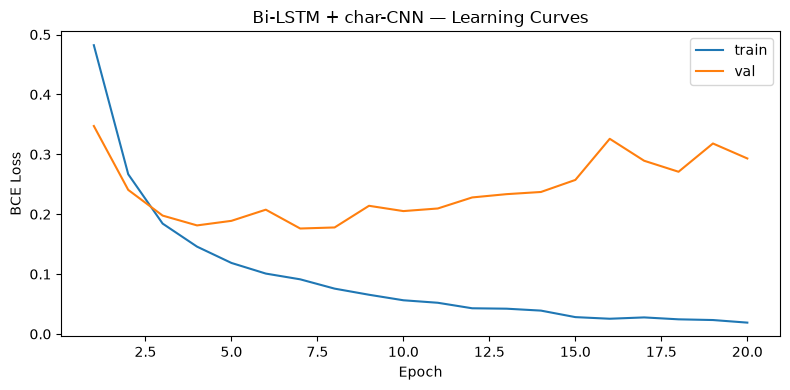

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
epochs_range = range(1, len(history["train_loss"]) + 1)
ax.plot(epochs_range, history["train_loss"], label="train")
ax.plot(epochs_range, history["val_loss"],   label="val")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("Bi-LSTM + char-CNN — Learning Curves")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Load Best Checkpoint

In [15]:
CKPT     = CHECKPOINT_DIR / "best_model.pt"
VOC_PATH = CHECKPOINT_DIR / "vocab.json"

detector = BiLSTMDLPDetector(
    checkpoint_path=str(CKPT),
    vocab_path=str(VOC_PATH),
    device=str(DEVICE),
)
print(f"Loaded: {CKPT.name}")

Loaded: best_model.pt


## 8. Run Inference on Validation Set

In [16]:
THRESHOLD = 0.5

print(f"Running predict_proba on {len(val_texts):,} samples...")
y_proba = detector.predict_proba(val_texts)       # (N, 4) float32
y_pred  = (y_proba >= THRESHOLD).astype(np.int32) # (N, 4) int
y_true  = from_dataframe(val_df)                   # (N, 4) int

print(f"y_proba range: [{y_proba.min():.3f}, {y_proba.max():.3f}]")
print()
print(f"{'label':14s}  {'pred':>6s}  {'true':>6s}")
for i, col in enumerate(LABEL_COLS):
    print(f"  {col:12s}  {y_pred[:,i].sum():6d}  {y_true[:,i].sum():6d}")

Running predict_proba on 7,946 samples...
y_proba range: [0.000, 1.000]

label             pred    true
  benign          1200     908
  PII             6746    7038
  financial       1604    1529
  confidential    3637    3632


## 9. Metrics

In [17]:
metrics = compute_all_metrics(y_true, y_pred, y_proba=y_proba)

ci = metrics["macro_f1_ci"]
print(f"Macro-F1:      {metrics['macro_f1']:.4f}  "
      f"(95% CI: [{ci['lower']:.4f}, {ci['upper']:.4f}])")
print(f"Macro AUC-ROC: {metrics['auc_roc']['macro']:.4f}")
print()

pd.DataFrame(metrics["per_label"]).T.round(4)

Macro-F1:      0.9466  (95% CI: [0.9424, 0.9504])
Macro AUC-ROC: 0.9884



,precision,recall,f1,support
benign,0.7250,0.9581,0.8254,908.0
PII,0.9942,0.9530,0.9732,7038.0
financial,0.8940,0.9379,0.9154,1529.0
confidential,0.9505,0.9518,0.9512,3632.0


### 9a. Threshold Sensitivity (0.3 / 0.5 / 0.7)

In [18]:
rows = []
for t in [0.3, 0.5, 0.7]:
    m = compute_all_metrics(y_true, (y_proba >= t).astype(np.int32), n_bootstrap=50)
    row = {"threshold": t, "macro_f1": round(m["macro_f1"], 4)}
    for label in LABEL_COLS:
        row[f"{label}_f1"] = round(m["per_label"][label]["f1"], 4)
    rows.append(row)

pd.DataFrame(rows).set_index("threshold")

,macro_f1,benign_f1,PII_f1,financial_f1,confidential_f1
threshold,,,,,
0.3,0.9370,0.8048,0.9762,0.8850,0.9497
0.5,0.9466,0.8254,0.9732,0.9154,0.9512
0.7,0.9493,0.8386,0.9693,0.9289,0.9495


## 10. Confusion Matrices & Per-Label Bars

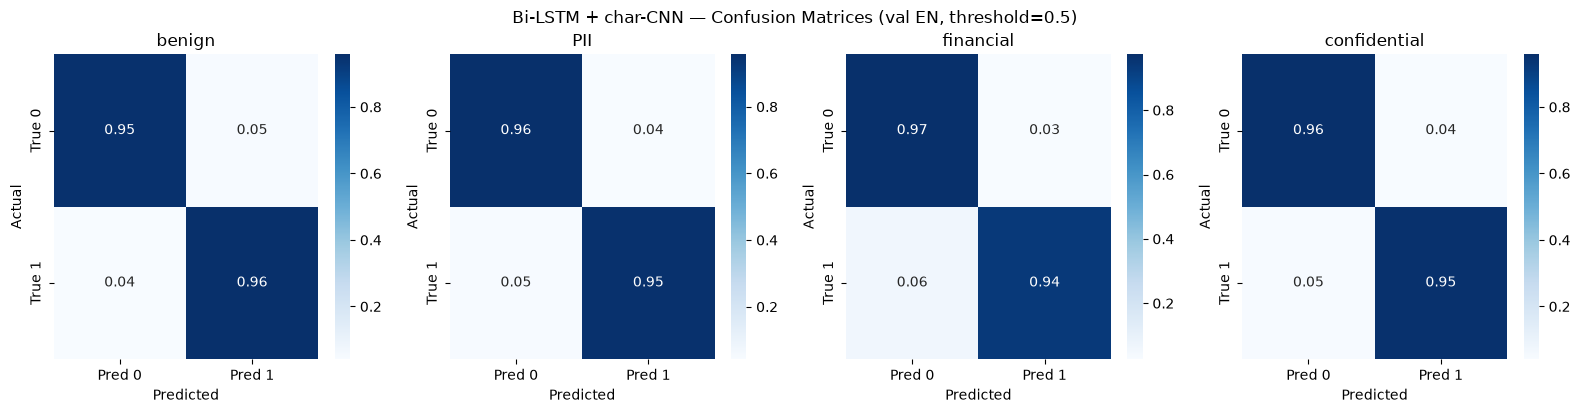

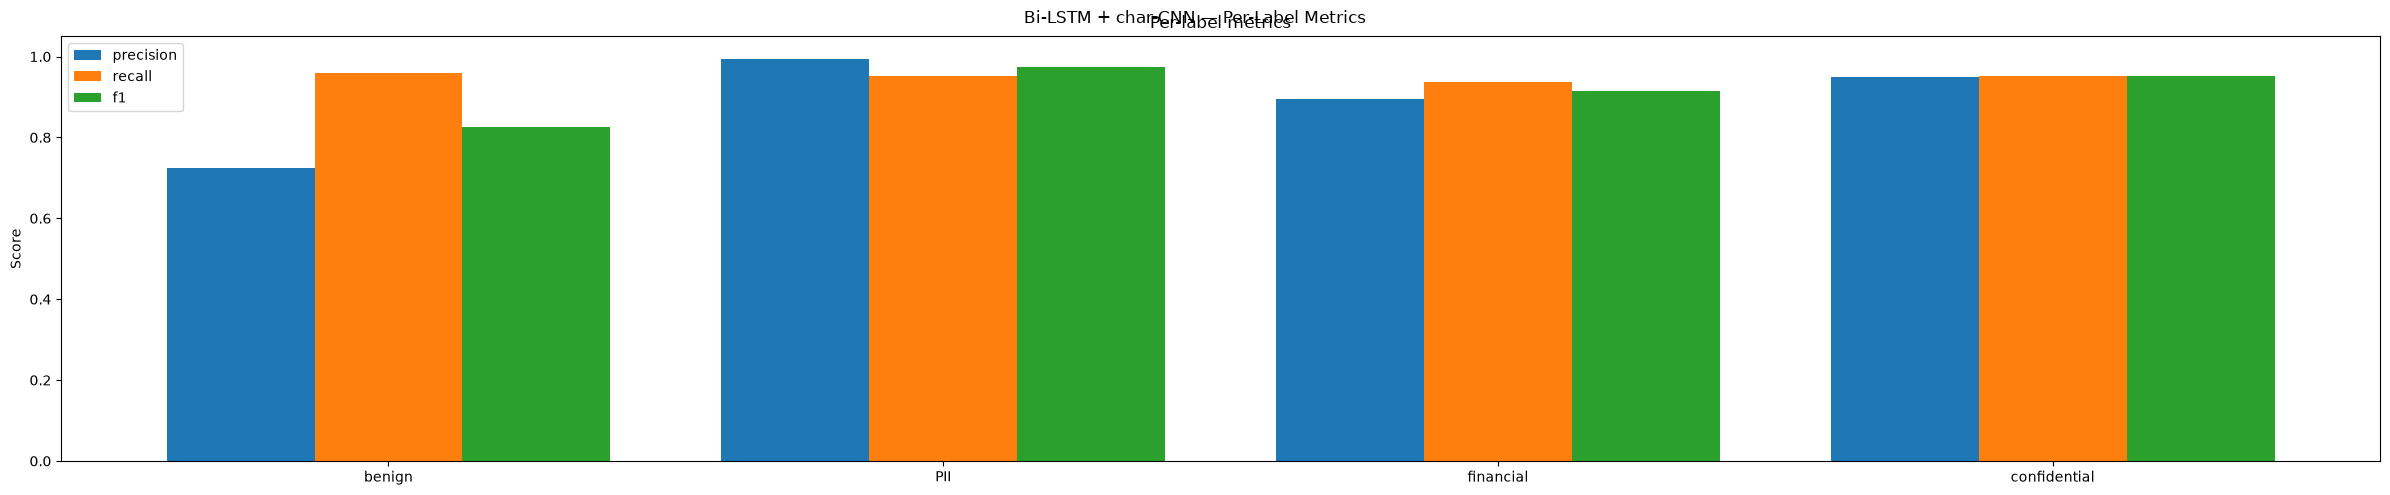

In [19]:
_, fig = plot_confusion_matrices(y_true, y_pred, normalize="true", return_fig=True)
fig.suptitle("Bi-LSTM + char-CNN — Confusion Matrices (val EN, threshold=0.5)", y=1.02)
plt.show()

_, bar_fig = plot_per_label_bars(metrics, return_fig=True)
bar_fig.suptitle("Bi-LSTM + char-CNN — Per-Label Metrics")
plt.show()

## 11. ROC & PR Curves

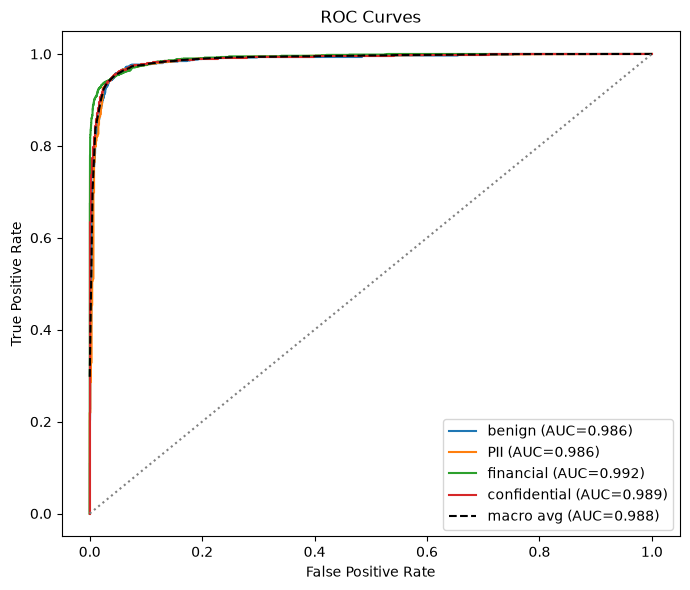

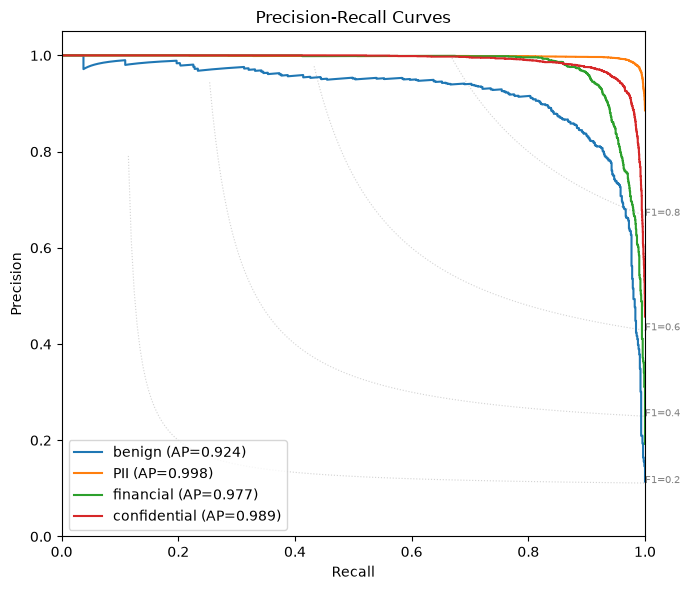

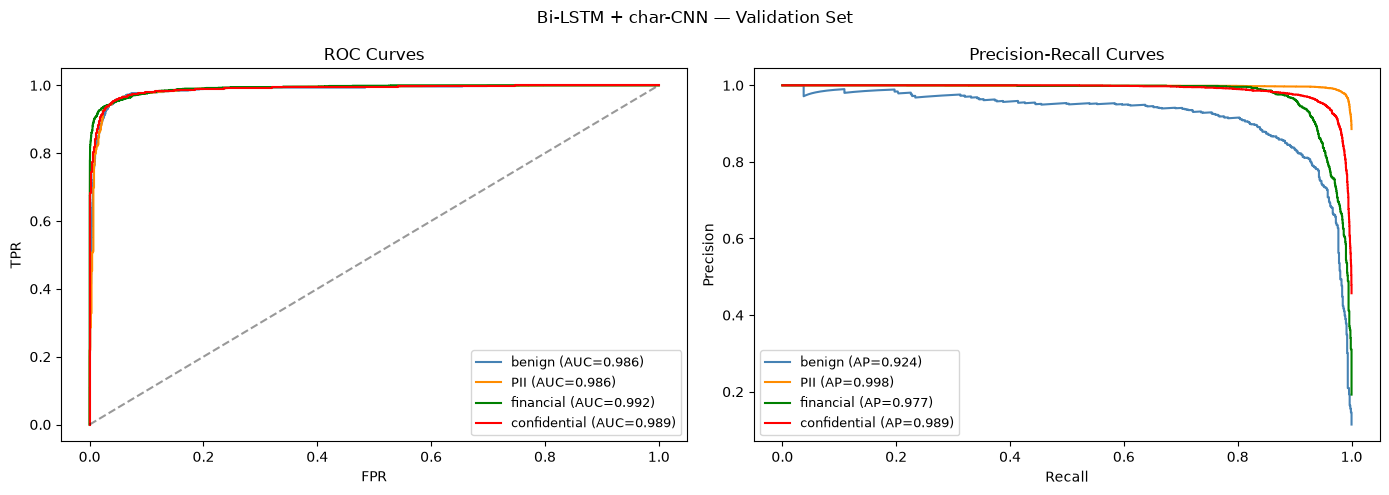

In [20]:
roc_data = plot_roc_curves(y_true, y_proba)
pr_data  = plot_pr_curves(y_true, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
COLORS = ["steelblue", "darkorange", "green", "red"]

for i, label in enumerate(LABEL_COLS):
    axes[0].plot(roc_data[label]["fpr"], roc_data[label]["tpr"],
                 label=f"{label} (AUC={roc_data[label]['auc']:.3f})", color=COLORS[i])
    axes[1].plot(pr_data[label]["recall"], pr_data[label]["precision"],
                 label=f"{label} (AP={pr_data[label]['ap']:.3f})", color=COLORS[i])

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=9)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=9)
fig.suptitle("Bi-LSTM + char-CNN — Validation Set")
plt.tight_layout()
plt.show()

## 12. Error Analysis

Classifies FP/FN into the four taxonomy buckets (descriptive error analysis for RQ1/RQ2 model comparison).

In [21]:
texts = val_df["source_text"].tolist()

error_results = classify_errors(
    texts, y_true, y_pred,
    max_examples=20,
)

summary_df = error_summary(error_results)
print("Error counts by type and label:")
display(summary_df.pivot(index="error_type", columns="label", values="count").fillna(0).astype(int))

Error counts by type and label:


label,PII,benign,confidential,financial
error_type,,,,
FN_implicit,0,1,8,2
FN_obfuscated,2,0,11,3
FP_hypothetical,0,7,4,1
FP_negation,3,20,9,7
other_FN,20,20,20,20
other_FP,20,20,20,20


In [22]:
def show_bucket(key: str, n: int = 5) -> None:
    records = error_results.get(key, [])
    print(f"\n{'─'*60}")
    print(f"{key}  ({len(records)} total, showing {min(n, len(records))})")
    print(f"{'─'*60}")
    for r in records[:n]:
        print(f"  [{r['label']}] {r['text_snippet'][:120].replace(chr(10), ' ')}")

show_bucket("FP_negation")
show_bucket("FP_hypothetical")
show_bucket("FN_obfuscated")
show_bucket("FN_implicit")


────────────────────────────────────────────────────────────
FP_negation  (39 total, showing 5)
────────────────────────────────────────────────────────────
  [benign]             <King>                 </SEX_J>                 <Prefer not to disclose>                     <Excellence>   
  [benign] oring sessions. 3.2 Should the Tutor need to cancel a session for unforeseen circumstances, a makeup session will be sch
  [financial]  to detail have truly enhanced the quality of our project.   I would also like to acknowledge **384989248**, **393981823
  [benign] ssues and remind everyone of the importance of academic integrity.  Individuals involved in academic dishonesty must und
  [confidential] sponsible for all activities conducted under their accounts. 2. Users must maintain the confidentiality of their login c

────────────────────────────────────────────────────────────
FP_hypothetical  (12 total, showing 5)
────────────────────────────────────────────────────────────
  [confiden

## 13. Save Results

In [19]:
out_path = RESULTS_DIR / "bilstm_metrics.json"

save_results(
    metrics,
    path=out_path,
    model_name="bilstm_charcnn",
    n_samples=len(val_df),
    threshold=THRESHOLD,
    extra_metadata={
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "vocab_size": vocab.n_words,
        # Real loaded status from _load_glove (was GLOVE_PATH.exists() — comment 012).
        "glove_available": bool(GLOVE_LOADED),
        "use_char_cnn": bool(USE_CHAR_CNN),
        "freeze_word_emb": bool(GLOVE_LOADED),
        "checkpoint": str(CKPT),
    },
)

print(f"Saved to {out_path}")

NameError: name 'EPOCHS' is not defined

## 14. Cross-Validation Robustness (5-fold on train split)

CV was run on the ai4privacy **train** split; the held-out **validation** (test) split
was never touched. Results show mean ± std across 5 folds, confirming that the
single-run test metrics are not a lucky split.

In [23]:
import json

kfold_path = RESULTS_DIR / "kfold_cv_bilstm.json"
with open(kfold_path) as f:
    kfold = json.load(f)

agg = kfold["aggregated"]

rows = []
for label in LABEL_COLS:
    cv_mean = agg["per_label"][label]["f1_mean"]
    cv_std  = agg["per_label"][label]["f1_std"]
    test_f1 = metrics["per_label"][label]["f1"]
    rows.append({
        "label":           label,
        "CV mean F1":      round(cv_mean, 4),
        "CV std":          round(cv_std,  4),
        "Test F1":         round(test_f1, 4),
        "delta (test-CV)": round(test_f1 - cv_mean, 4),
    })

rows.append({
    "label":           "MACRO",
    "CV mean F1":      round(agg["macro_f1_mean"], 4),
    "CV std":          round(agg["macro_f1_std"],  4),
    "Test F1":         round(metrics["macro_f1"],  4),
    "delta (test-CV)": round(metrics["macro_f1"] - agg["macro_f1_mean"], 4),
})

cv_df = pd.DataFrame(rows).set_index("label")
print(f"CV config: {agg['configuration']}  |  k={kfold['k']}  |  seed={kfold['seed']}")
display(cv_df)

CV config: solo_bilstm  |  k=5  |  seed=42


,CV mean F1,CV std,Test F1,delta (test-CV)
label,,,,
benign,0.8402,0.0229,0.8254,-0.0148
PII,0.9757,0.0043,0.9732,-0.0025
financial,0.9049,0.0156,0.9154,0.0105
confidential,0.9431,0.0064,0.9512,0.0080
MACRO,0.9412,0.0064,0.9466,0.0054


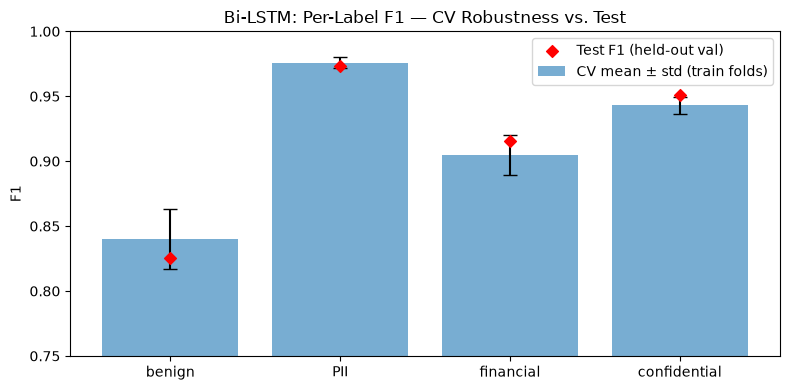

In [24]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(LABEL_COLS))
cv_means = [agg["per_label"][l]["f1_mean"] for l in LABEL_COLS]
cv_stds  = [agg["per_label"][l]["f1_std"]  for l in LABEL_COLS]
test_f1s = [metrics["per_label"][l]["f1"] for l in LABEL_COLS]

ax.bar(x, cv_means, yerr=cv_stds, capsize=5, alpha=0.6, label="CV mean ± std (train folds)")
ax.scatter(x, test_f1s, marker="D", color="red", zorder=5, label="Test F1 (held-out val)")
ax.set_xticks(list(x))
ax.set_xticklabels(LABEL_COLS)
ax.set_ylabel("F1")
ax.set_ylim(0.75, 1.0)
ax.set_title("Bi-LSTM: Per-Label F1 — CV Robustness vs. Test")
ax.legend()
plt.tight_layout()
plt.show()